In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "diffusion_policy"))

In [6]:
from diffusion_policy.env.block_pushing.block_pushing_multimodal import (
    BlockPushMultimodal,
)
from diffusion_policy.env.pusht.pusht_image_env import (
    PushTImageEnv,
)


pygame 2.1.2 (SDL 2.0.16, Python 3.9.15)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [25]:
env = PushTImageEnv()
env.reset()

{'image': array([[[1.        , 0.972549  , 0.972549  , ..., 0.972549  ,
          0.972549  , 1.        ],
         [0.972549  , 0.87058824, 0.9137255 , ..., 0.9137255 ,
          0.87058824, 0.972549  ],
         [0.96862745, 0.9137255 , 1.        , ..., 1.        ,
          0.9137255 , 0.96862745],
         ...,
         [0.96862745, 0.9137255 , 1.        , ..., 1.        ,
          0.9137255 , 0.96862745],
         [0.972549  , 0.87058824, 0.9137255 , ..., 0.9137255 ,
          0.87058824, 0.972549  ],
         [1.        , 0.972549  , 0.972549  , ..., 0.972549  ,
          0.972549  , 1.        ]],
 
        [[1.        , 0.972549  , 0.972549  , ..., 0.972549  ,
          0.972549  , 1.        ],
         [0.972549  , 0.87058824, 0.9137255 , ..., 0.9137255 ,
          0.87058824, 0.972549  ],
         [0.96862745, 0.9137255 , 1.        , ..., 1.        ,
          0.9137255 , 0.96862745],
         ...,
         [0.96862745, 0.9137255 , 1.        , ..., 1.        ,
          0.913

In [21]:
env = BlockPushMultimodal()
env.reset()

argv[0]=


OrderedDict([('block_translation',
              (0.38111619410558834, -0.16670662387341473)),
             ('block_orientation', array([1.60129451])),
             ('block2_translation',
              (0.4908988295881691, -0.19203747276936292)),
             ('block2_orientation', array([2.37417301])),
             ('effector_translation', array([ 0.30025086, -0.39858914])),
             ('effector_target_translation', array([ 0.3, -0.4])),
             ('target_translation', array([0.51559581, 0.20594473])),
             ('target_orientation', array([3.0693439])),
             ('target2_translation', array([0.28118071, 0.20073116])),
             ('target2_orientation', array([3.09703478]))])

In [22]:
action = env.action_space.sample()
obs, reward, done, info = env.step(action)

In [23]:
obs

OrderedDict([('block_translation', (0.3811152603519126, -0.16670645895574612)),
             ('block_orientation', array([1.60129217])),
             ('block2_translation',
              (0.49089710879876786, -0.1920382107418181)),
             ('block2_orientation', array([2.37416045])),
             ('effector_translation', array([ 0.33121779, -0.41392427])),
             ('effector_target_translation',
              array([ 0.33436404, -0.4169909 ])),
             ('target_translation', array([0.51559581, 0.20594473])),
             ('target_orientation', array([3.0693439])),
             ('target2_translation', array([0.28118071, 0.20073116])),
             ('target2_orientation', array([3.09703478]))])

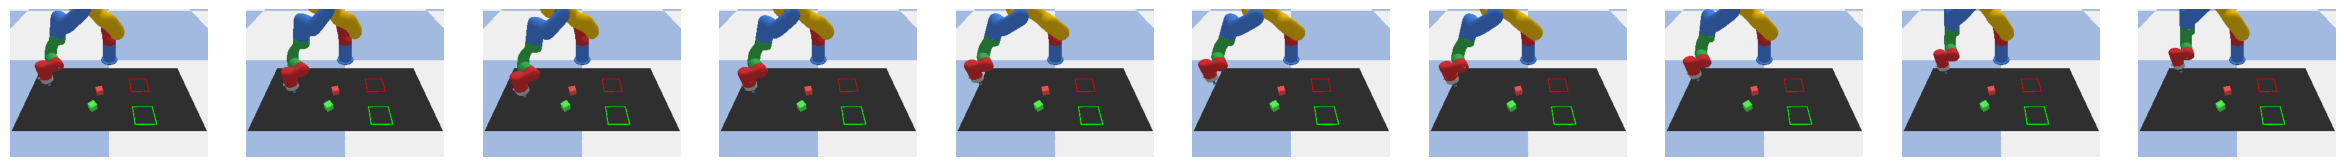

In [ ]:
import matplotlib.pyplot as plt


def display_env_action_frames(env, num_steps=10):
    frames = []
    obs = env.reset()
    for _ in range(num_steps):
        action = env.action_space.sample()
        obs, reward, done, info = env.step(action)
        frame = env.render(mode='rgb_array')
        frames.append(frame)
        if done:
            obs = env.reset()
    # Display frames with larger images
    fig, axes = plt.subplots(1, len(frames), figsize=(3 * len(frames), 8))
    for ax, frame in zip(axes, frames):
        ax.imshow(frame)
        ax.axis('off')
    plt.show()

display_env_action_frames(env, num_steps=10)


2025-08-18 21:43:41,154 [INFO] Block 1 moved on step 3
2025-08-18 21:43:41,231 [INFO] Block 0 moved on step 5


GIF saved as my_simulation.gif


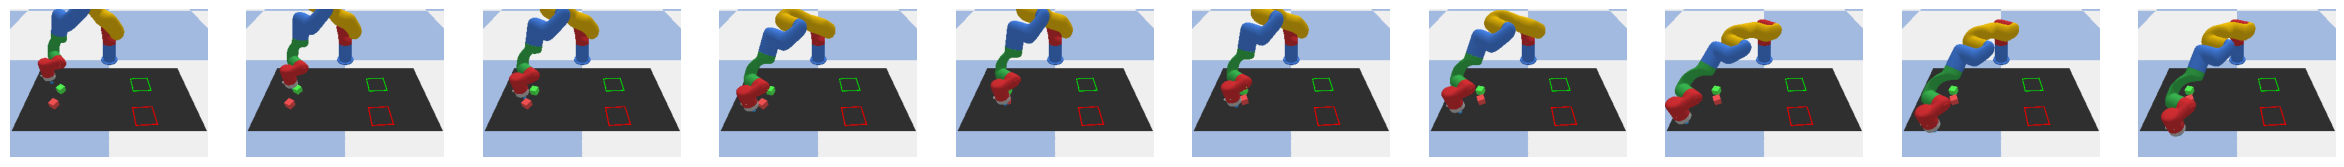

In [ ]:
from PIL import Image


def display_env_action_frames(env, num_steps=10, save_gif=True, gif_name="simulation.gif"):
    frames = []
    obs = env.reset()

    for i in range(num_steps):
        action = env.action_space.sample()
        obs, reward, done, info = env.step(action)
        frame = env.render(mode='rgb_array')
        frames.append(frame)
        if done:
            obs = env.reset()

    # Save as GIF
    if save_gif:
        # Convert frames to PIL Images
        pil_frames = [Image.fromarray(frame) for frame in frames]
        # Save as GIF with 500ms duration per frame
        pil_frames[0].save(gif_name, save_all=True, append_images=pil_frames[1:],
                          duration=500, loop=0)
        print(f"GIF saved as {gif_name}")

    # Display frames with larger images
    fig, axes = plt.subplots(1, len(frames), figsize=(3 * len(frames), 8))
    for ax, frame in zip(axes, frames):
        ax.imshow(frame)
        ax.axis('off')
    plt.show()

# Usage
display_env_action_frames(env, num_steps=10, save_gif=True, gif_name="my_simulation.gif")

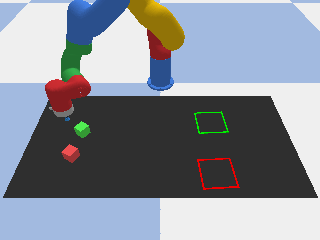

In [ ]:
from IPython.display import Image as IPImage

IPImage("my_simulation.gif")

In [ ]:
import gym
import numpy as np
from gym import spaces


class LanguageInstructionWrapper(gym.Wrapper):
    def __init__(self, env, instruction_set=None):
        super().__init__(env)

        # Create instruction set
        self.instructions = instruction_set or [
            "Push the red block to the green square",
            "Move the blue block away from the red block",
            "Arrange blocks in a line",
            "Stack the green block on top of the red block"
        ]

        # Modify observation space to include text
        self.observation_space = spaces.Dict({
            'image': env.observation_space,  # original obs
            'instruction': spaces.Text(max_length=100)
        })

    def reset(self):
        obs = self.env.reset()
        # Sample random instruction
        self.current_instruction = np.random.choice(self.instructions)
        return {
            'image': obs,
            'instruction': self.current_instruction
        }

    def step(self, action):
        obs, reward, done, info = self.env.step(action)
        return {
            'image': obs,
            'instruction': self.current_instruction
        }, reward, done, info

# Robomimic


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent / "diffusion_policy"))

In [2]:
from diffusion_policy.env.robomimic.robomimic_image_wrapper import (
RobomimicImageWrapper,
)

/home/thankgod/conda/envs/robodiff/lib/python3.9/site-packages/llvmlite/binding/ffi.py:175: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/home/thankgod/conda/envs/robodiff/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from pathlib import Path

In [ ]:
import os

from omegaconf import OmegaConf

In [ ]:
import robomimic.utils.env_utils as EnvUtils
import robomimic.utils.file_utils as FileUtils

In [6]:
cfg_path = Path(os.getcwd()).parent / 'image_lift_ph_diffusion_policy_cnn.yaml'
cfg = OmegaConf.load(cfg_path)
shape_meta = cfg['shape_meta']
shape_meta

{'action': {'shape': [10]}, 'obs': {'agentview_image': {'shape': [3, 84, 84], 'type': 'rgb'}, 'robot0_eef_pos': {'shape': [3]}, 'robot0_eef_quat': {'shape': [4]}, 'robot0_eye_in_hand_image': {'shape': [3, 84, 84], 'type': 'rgb'}, 'robot0_gripper_qpos': {'shape': [2]}}}

In [ ]:
from robomimic.utils.obs_utils import initialize_obs_utils_with_config

#from robomimic.config import config_factory

initialize_obs_utils_with_config(cfg)

ConfigAttributeError: Missing key algo_name
    full_key: algo_name
    object_type=dict

In [ ]:


# Then create your environment
env = EnvUtils.create_env_from_metadata(
    env_meta=env_meta,
    render=False,
    render_offscreen=True,
    use_image_obs=False,
)

In [13]:
env_meta

{'env_name': 'Lift',
 'type': 1,
 'env_kwargs': {'has_renderer': False,
  'has_offscreen_renderer': True,
  'ignore_done': True,
  'use_object_obs': True,
  'use_camera_obs': True,
  'control_freq': 20,
  'controller_configs': {'type': 'OSC_POSE',
   'input_max': 1,
   'input_min': -1,
   'output_max': [0.05, 0.05, 0.05, 0.5, 0.5, 0.5],
   'output_min': [-0.05, -0.05, -0.05, -0.5, -0.5, -0.5],
   'kp': 150,
   'damping': 1,
   'impedance_mode': 'fixed',
   'kp_limits': [0, 300],
   'damping_limits': [0, 10],
   'position_limits': None,
   'orientation_limits': None,
   'uncouple_pos_ori': True,
   'control_delta': True,
   'interpolation': None,
   'ramp_ratio': 0.2},
  'robots': ['Panda'],
  'camera_depths': False,
  'camera_heights': 84,
  'camera_widths': 84,
  'reward_shaping': False,
  'camera_names': ['agentview', 'robot0_eye_in_hand'],
  'render_gpu_device_id': 0}}

In [32]:
lift_dataset_path = Path(os.getcwd()).parent / 'data/robomimic/datasets/square/ph/image.hdf5'
lift_dataset_path

PosixPath('/home/thankgod/2025/diffusion_policy_repo/diffusion_policy/data/robomimic/datasets/square/ph/image.hdf5')

In [34]:
from rich import print

In [35]:
env_meta = FileUtils.get_env_metadata_from_dataset(
    str(lift_dataset_path)
    )
print(env_meta)

{
    'env_name': 'NutAssemblySquare',
    'type': 1,
    'env_kwargs': {
        'has_renderer': False,
        'has_offscreen_renderer': True,
        'ignore_done': True,
        'use_object_obs': True,
        'use_camera_obs': True,
        'control_freq': 20,
        'controller_configs': {
            'type': 'OSC_POSE',
            'input_max': 1,
            'input_min': -1,
            'output_max': [0.05, 0.05, 0.05, 0.5, 0.5, 0.5],
            'output_min': [-0.05, -0.05, -0.05, -0.5, -0.5, -0.5],
            'kp': 150,
            'damping': 1,
            'impedance_mode': 'fixed',
            'kp_limits': [0, 300],
            'damping_limits': [0, 10],
            'position_limits': None,
            'orientation_limits': None,
            'uncouple_pos_ori': True,
            'control_delta': True,
            'interpolation': None,
            'ramp_ratio': 0.2
        },
        'robots': ['Panda'],
        'camera_depths': False,
        'camera_heights': 84,
        'camera_widths': 84,
        'reward_shaping': False,
        'camera_names': ['agentview', 'robot0_eye_in_hand'],
        'render_gpu_device_id': 0
    }
}

In [ ]:
env_meta = FileUtils.get_env_metadata_from_dataset(
    str(lift_dataset_path)
    )

env = EnvUtils.create_env_from_metadata(
    env_meta=env_meta,
    render=False,
    render_offscreen=False,
    use_image_obs=True,
)

env.reset()

INFO:root:Device 0 is available for rendering
INFO:root:Command '['/home/thankgod/conda/envs/robodiff/lib/python3.9/site-packages/egl_probe/build/test_device', '2']' returned non-zero exit status 1.
INFO:root:Device 2 is not available for rendering


Created environment with name NutAssemblySquare
Action size is 7


TypeError: argument of type 'NoneType' is not iterable

In [ ]:


wrapper = RobomimicImageWrapper(
    env=env,
    shape_meta=shape_meta
)
wrapper.seed(0)
obs = wrapper.reset()
img = wrapper.render()
plt.imshow(img)

INFO:root:Device 0 is available for rendering
INFO:root:Command '['/home/thankgod/conda/envs/robodiff/lib/python3.9/site-packages/egl_probe/build/test_device', '2']' returned non-zero exit status 1.
INFO:root:Device 2 is not available for rendering


Created environment with name Lift
Action size is 7


TypeError: argument of type 'NoneType' is not iterable

In [9]:
env

NutAssemblySquare
{
    "camera_depths": false,
    "camera_heights": 84,
    "camera_names": [
        "agentview",
        "robot0_eye_in_hand"
    ],
    "camera_widths": 84,
    "control_freq": 20,
    "controller_configs": {
        "control_delta": true,
        "damping": 1,
        "damping_limits": [
            0,
            10
        ],
        "impedance_mode": "fixed",
        "input_max": 1,
        "input_min": -1,
        "interpolation": null,
        "kp": 150,
        "kp_limits": [
            0,
            300
        ],
        "orientation_limits": null,
        "output_max": [
            0.05,
            0.05,
            0.05,
            0.5,
            0.5,
            0.5
        ],
        "output_min": [
            -0.05,
            -0.05,
            -0.05,
            -0.5,
            -0.5,
            -0.5
        ],
        "position_limits": null,
        "ramp_ratio": 0.2,
        "type": "OSC_POSE",
        "uncouple_pos_ori": true
    },
 

In [ ]:
from diffusion_policy.env_runner.robomimic_image_runner import RobomimicImageRunner


In [ ]:
cfg = OmegaConf.load(cfg_path)
cfg['n_obs_steps'] = 1
cfg['n_action_steps'] = 1
cfg['past_action_visible'] = False
runner_cfg = cfg['env_runner']
runner_cfg['n_train'] = 1
runner_cfg['n_test'] = 1
del runner_cfg['_target_']
runner = RobomimicImageRunner(
    **runner_cfg,
    output_dir='/tmp/test')

# import pdb; pdb.set_trace()

self = runner
env = self.env
env.seed(seeds=self.env_seeds)
obs = env.reset()
for i in range(10):
    _ = env.step(env.action_space.sample())

imgs = env.render()

In [37]:
# Update your env_meta to enable camera observations
env_meta['env_kwargs']['use_camera_obs'] = True
env_meta['env_kwargs']['has_offscreen_renderer'] = True

# Also ensure camera settings match your config
env_meta['env_kwargs']['camera_heights'] = 84  # Already correct
env_meta['env_kwargs']['camera_widths'] = 84   # Already correct

# Make sure you have the right camera names
env_meta['env_kwargs']['camera_names'] = ['agentview', 'robot0_eye_in_hand']

In [ ]:
import os
from pathlib import Path

from omegaconf import OmegaConf

#from robomimic.utils.env_utils import EnvUtils
import robomimic.utils.env_utils as EnvUtils

# Load your config
cfg_path = Path(os.getcwd()).parent / 'image_lift_ph_diffusion_policy_cnn.yaml'
cfg = OmegaConf.load(cfg_path)
shape_meta = cfg['shape_meta']

# Update env_meta to match your config requirements
env_meta['env_kwargs']['use_camera_obs'] = True
env_meta['env_kwargs']['has_offscreen_renderer'] = True
env_meta['env_kwargs']['camera_names'] = ['agentview', 'robot0_eye_in_hand']

# Now create the environment - this should work
env = EnvUtils.create_env_from_metadata(
    env_meta=env_meta,
    render=False,
    render_offscreen=True,
    use_image_obs=True,  # Change this to True since you need images
)

# This should now work without the TypeError
obs = env.reset()

INFO:root:Device 0 is available for rendering
INFO:root:Command '['/home/thankgod/conda/envs/robodiff/lib/python3.9/site-packages/egl_probe/build/test_device', '2']' returned non-zero exit status 1.
INFO:root:Device 2 is not available for rendering


Created environment with name NutAssemblySquare
Action size is 7


TypeError: argument of type 'NoneType' is not iterable

In [40]:
from robomimic.utils.obs_utils import initialize_obs_utils_with_obs_specs

# Create observation specs from your shape_meta
obs_modality_specs = {
    "obs": {
        "low_dim": ["robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"],
        "rgb": ["agentview_image", "robot0_eye_in_hand_image"],
        "depth": [],
        "scan": []
    }
}

# Initialize ObsUtils
initialize_obs_utils_with_obs_specs(obs_modality_specs)

# Then create your environment
env_meta['env_kwargs']['use_camera_obs'] = True
env_meta['env_kwargs']['has_offscreen_renderer'] = True
env_meta['env_kwargs']['camera_names'] = ['agentview', 'robot0_eye_in_hand']

env = EnvUtils.create_env_from_metadata(
    env_meta=env_meta,
    render=False,
    render_offscreen=True,
    use_image_obs=True,
)


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'robot0_eef_pos', 'robot0_eef_quat']
using obs modality: rgb with keys: ['robot0_eye_in_hand_image', 'agentview_image']
using obs modality: depth with keys: []
using obs modality: scan with keys: []


INFO:root:Device 0 is available for rendering
INFO:root:Command '['/home/thankgod/conda/envs/robodiff/lib/python3.9/site-packages/egl_probe/build/test_device', '2']' returned non-zero exit status 1.
INFO:root:Device 2 is not available for rendering


Created environment with name NutAssemblySquare
Action size is 7


In [41]:
env.reset()

{'agentview_image': array([[[0.38431373, 0.3882353 , 0.3882353 , ..., 0.39215687,
          0.39215687, 0.39215687],
         [0.3882353 , 0.38431373, 0.38431373, ..., 0.39215687,
          0.39215687, 0.39215687],
         [0.38431373, 0.38431373, 0.38039216, ..., 0.39215687,
          0.38431373, 0.3882353 ],
         ...,
         [0.9372549 , 0.9372549 , 0.9411765 , ..., 0.99215686,
          0.9882353 , 0.9882353 ],
         [0.9411765 , 0.94509804, 0.9490196 , ..., 0.99215686,
          0.99215686, 0.9882353 ],
         [0.9490196 , 0.94509804, 0.94509804, ..., 0.9882353 ,
          0.9882353 , 0.9882353 ]],
 
        [[0.3764706 , 0.38039216, 0.38039216, ..., 0.38431373,
          0.3882353 , 0.38431373],
         [0.38039216, 0.38039216, 0.38039216, ..., 0.38431373,
          0.38431373, 0.3882353 ],
         [0.37254903, 0.3764706 , 0.36862746, ..., 0.38431373,
          0.3764706 , 0.3764706 ],
         ...,
         [0.9372549 , 0.9411765 , 0.9411765 , ..., 0.9882353 ,
     

In [ ]:
import matplotlib.pyplot as plt


def display_env_action_frames(env, num_steps=10, save_gif=True, gif_name="simulation.gif"):
    frames = []
    obs = env.reset()

    for i in range(num_steps):
        action = env.action_space.sample()
        obs, reward, done, info = env.step(action)
        frame = env.render(mode='rgb_array')
        frames.append(frame)
        if done:
            obs = env.reset()

    # Save as GIF
    if save_gif:
        # Convert frames to PIL Images
        pil_frames = [Image.fromarray(frame) for frame in frames]
        # Save as GIF with 500ms duration per frame
        pil_frames[0].save(gif_name, save_all=True, append_images=pil_frames[1:],
                          duration=500, loop=0)
        print(f"GIF saved as {gif_name}")

    # Display frames with larger images
    fig, axes = plt.subplots(1, len(frames), figsize=(3 * len(frames), 8))
    for ax, frame in zip(axes, frames):
        ax.imshow(frame)
        ax.axis('off')
    plt.show()

# Usage
display_env_action_frames(env, num_steps=10, save_gif=True, gif_name="my_simulation.gif")

AttributeError: 'EnvRobosuite' object has no attribute 'action_space'

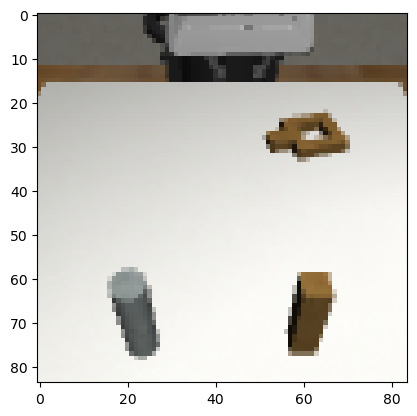

In [43]:
wrapper = RobomimicImageWrapper(
    env=env,
    shape_meta=shape_meta
)
wrapper.seed(0)
obs = wrapper.reset()
img = wrapper.render()
plt.imshow(img)

In [44]:
print(obs)

{
    'agentview_image': array([[[0.38431373, 0.3882353 , 0.3882353 , ..., 0.39215687,
         0.39215687, 0.39215687],
        [0.3882353 , 0.38431373, 0.38431373, ..., 0.39215687,
         0.39215687, 0.39215687],
        [0.38431373, 0.38431373, 0.38039216, ..., 0.39215687,
         0.38431373, 0.3882353 ],
        ...,
        [0.9372549 , 0.9372549 , 0.9411765 , ..., 0.99215686,
         0.9882353 , 0.9882353 ],
        [0.9411765 , 0.94509804, 0.9490196 , ..., 0.99215686,
         0.99215686, 0.9882353 ],
        [0.9490196 , 0.94509804, 0.94509804, ..., 0.9882353 ,
         0.9882353 , 0.9882353 ]],

       [[0.3764706 , 0.38039216, 0.38039216, ..., 0.38431373,
         0.3882353 , 0.38431373],
        [0.38039216, 0.38039216, 0.38039216, ..., 0.38431373,
         0.38431373, 0.3882353 ],
        [0.37254903, 0.3764706 , 0.36862746, ..., 0.38431373,
         0.3764706 , 0.3764706 ],
        ...,
        [0.9372549 , 0.9411765 , 0.9411765 , ..., 0.9882353 ,
         0.9843137 , 0.9843137 ],
        [0.9411765 , 0.9411765 , 0.94509804, ..., 0.9882353 ,
         0.9843137 , 0.9882353 ],
        [0.94509804, 0.9411765 , 0.94509804, ..., 0.9882353 ,
         0.9843137 , 0.9843137 ]],

       [[0.3529412 , 0.35686275, 0.35686275, ..., 0.36078432,
         0.3647059 , 0.3647059 ],
        [0.35686275, 0.35686275, 0.35686275, ..., 0.36078432,
         0.36078432, 0.36078432],
        [0.34901962, 0.3529412 , 0.34509805, ..., 0.36078432,
         0.34901962, 0.3529412 ],
        ...,
        [0.92156863, 0.92156863, 0.92156863, ..., 0.96862745,
         0.96862745, 0.96862745],
        [0.92156863, 0.9254902 , 0.9254902 , ..., 0.972549  ,
         0.972549  , 0.96862745],
        [0.9254902 , 0.92156863, 0.9254902 , ..., 0.96862745,
         0.96862745, 0.96862745]]], dtype=float32),
    'robot0_eef_pos': array([-0.08556123,  0.02520046,  1.01952552]),
    'robot0_eef_quat': array([ 9.97365447e-01, -1.06907561e-04,  7.18508744e-02, -9.98025943e-03]),
    'robot0_eye_in_hand_image': array([[[0.99215686, 0.9882353 , 0.9882353 , ..., 0.972549  ,
         0.972549  , 0.96862745],
        [0.9882353 , 0.99215686, 0.99215686, ..., 0.972549  ,
         0.972549  , 0.972549  ],
        [0.99215686, 0.9882353 , 0.99215686, ..., 0.972549  ,
         0.9764706 , 0.972549  ],
        ...,
        [0.28235295, 0.28235295, 0.28235295, ..., 0.27450982,
         0.27450982, 0.27450982],
        [0.28235295, 0.28235295, 0.28235295, ..., 0.2784314 ,
         0.2784314 , 0.2784314 ],
        [0.28235295, 0.28235295, 0.28235295, ..., 0.2784314 ,
         0.2784314 , 0.2784314 ]],

       [[0.9882353 , 0.9843137 , 0.9882353 , ..., 0.972549  ,
         0.972549  , 0.96862745],
        [0.9882353 , 0.9843137 , 0.9843137 , ..., 0.96862745,
         0.96862745, 0.96862745],
        [0.9882353 , 0.9843137 , 0.9843137 , ..., 0.96862745,
         0.972549  , 0.96862745],
        ...,
        [0.28235295, 0.28235295, 0.28235295, ..., 0.27450982,
         0.27450982, 0.27450982],
        [0.28235295, 0.28235295, 0.28235295, ..., 0.2784314 ,
         0.2784314 , 0.2784314 ],
        [0.28235295, 0.28235295, 0.28235295, ..., 0.2784314 ,
         0.2784314 , 0.2784314 ]],

       [[0.96862745, 0.972549  , 0.972549  , ..., 0.9529412 ,
         0.9529412 , 0.9490196 ],
        [0.972549  , 0.972549  , 0.972549  , ..., 0.9490196 ,
         0.9529412 , 0.9529412 ],
        [0.972549  , 0.972549  , 0.972549  , ..., 0.9490196 ,
         0.9529412 , 0.9529412 ],
        ...,
        [0.28235295, 0.28235295, 0.28235295, ..., 0.27450982,
         0.27450982, 0.27450982],
        [0.28235295, 0.28235295, 0.28235295, ..., 0.2784314 ,
         0.2784314 , 0.2784314 ],
        [0.28235295, 0.28235295, 0.28235295, ..., 0.2784314 ,
         0.2784314 , 0.2784314 ]]], dtype=float32),
    'robot0_gripper_qpos': array([ 0.020833, -0.020833])
}

In [ ]:
import robomimic.utils.env_utils as EnvUtils
import robomimic.utils.file_utils as FileUtils
from robomimic.utils.obs_utils import initialize_obs_utils_with_obs_specs

# Your initialization code (already working)
obs_modality_specs = {
    "obs": {
        "low_dim": ["robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"],
        "rgb": ["agentview_image", "robot0_eye_in_hand_image"],
        "depth": [],
        "scan": []
    }
}
initialize_obs_utils_with_obs_specs(obs_modality_specs)

# Environment setup
env_meta['env_kwargs']['use_camera_obs'] = True
env_meta['env_kwargs']['has_offscreen_renderer'] = True
env_meta['env_kwargs']['camera_names'] = ['agentview', 'robot0_eye_in_hand']

env = EnvUtils.create_env_from_metadata(
    env_meta=env_meta,
    render=False,
    render_offscreen=True,
    use_image_obs=True,
)

# Random policy rollout
class RandomPolicy:
    def __init__(self, action_dim):
        self.action_dim = action_dim

    def __call__(self, obs):
        return np.random.uniform(-1, 1, size=self.action_dim)

# Run rollout
action_dim = cfg['shape_meta']['action']['shape'][0]
policy = RandomPolicy(action_dim)

obs = env.reset()
done = False
step_count = 0
max_steps = 1000

while not done and step_count < max_steps:
    action = policy(obs)
    obs, reward, done, info = env.step(action)
    step_count += 1
    if step_count % 100 == 0:
        print(f"Step {step_count}, Reward: {reward}")

print(f"Episode finished in {step_count} steps")

INFO:root:Device 0 is available for rendering



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'robot0_eef_pos', 'robot0_eef_quat']
using obs modality: rgb with keys: ['robot0_eye_in_hand_image', 'agentview_image']
using obs modality: depth with keys: []
using obs modality: scan with keys: []


INFO:root:Command '['/home/thankgod/conda/envs/robodiff/lib/python3.9/site-packages/egl_probe/build/test_device', '2']' returned non-zero exit status 1.
INFO:root:Device 2 is not available for rendering


Created environment with name NutAssemblySquare
Action size is 7


AssertionError: environment got invalid action dimension -- expected 7, got 10

In [49]:
print(env)

NutAssemblySquare
{
    "camera_depths": false,
    "camera_heights": 84,
    "camera_names": [
        "agentview",
        "robot0_eye_in_hand"
    ],
    "camera_widths": 84,
    "control_freq": 20,
    "controller_configs": {
        "control_delta": true,
        "damping": 1,
        "damping_limits": [
            0,
            10
        ],
        "impedance_mode": "fixed",
        "input_max": 1,
        "input_min": -1,
        "interpolation": null,
        "kp": 150,
        "kp_limits": [
            0,
            300
        ],
        "orientation_limits": null,
        "output_max": [
            0.05,
            0.05,
            0.05,
            0.5,
            0.5,
            0.5
        ],
        "output_min": [
            -0.05,
            -0.05,
            -0.05,
            -0.5,
            -0.5,
            -0.5
        ],
        "position_limits": null,
        "ramp_ratio": 0.2,
        "type": "OSC_POSE",
        "uncouple_pos_ori": true
    },
    "has_offscreen_renderer": true,
    "has_renderer": false,
    "ignore_done": true,
    "render_gpu_device_id": 0,
    "reward_shaping": false,
    "robots": [
        "Panda"
    ],
    "use_camera_obs": true,
    "use_object_obs": true
}

In [50]:
# Check the action dimension
print("Environment action dimension:", env.env.action_dim)
print("Action spec:", env.env.action_spec)

# Also check what the controller expects
if hasattr(env.env, 'robots'):
    for robot in env.env.robots:
        print(f"Robot {robot.name} action dimension:", robot.action_dim)

Environment action dimension: 7

Action spec:
(array([-1., -1., -1., -1., -1., -1., -1.]), array([1., 1., 1., 1., 1., 1., 1.]))

Robot Panda action dimension: 7

In [ ]:
class RandomPolicy:
    def __init__(self, action_dim):
        self.action_dim = action_dim

    def __call__(self, obs):
        # For OSC_POSE controller: 6 DOF (position + orientation) + 1 gripper
        return np.random.uniform(-1, 1, size=self.action_dim)

# Use 7 dimensions as expected by the NutAssemblySquare environment
action_dim = 7  # 6 DOF pose + 1 gripper
policy = RandomPolicy(action_dim)

# Run rollout
obs = env.reset()
done = False
step_count = 0
max_steps = 1000

print(f"Starting NutAssemblySquare rollout with {action_dim}-dimensional actions...")

while not done and step_count < max_steps:
    action = policy(obs)
    obs, reward, done, info = env.step(action)
    step_count += 1

    if step_count % 100 == 0:
        print(f"Step {step_count}, Reward: {reward:.4f}")

    # Check for success (nut assembly tasks often have success criteria)
    if info.get('success', False):
        print(f"Success! Task completed in {step_count} steps")
        break

print(f"Episode finished in {step_count} steps")
print(f"Final reward: {reward:.4f}")
print(f"Success: {info.get('success', False)}")

Starting NutAssemblySquare rollout with 7-dimensional actions...

Step 100, Reward: 0.0000

Step 200, Reward: 0.0000

Step 300, Reward: 0.0000

Step 400, Reward: 0.0000

...

Step 900, Reward: 0.0000

Step 1000, Reward: 0.0000

Episode finished in 1000 steps

Final reward: 0.0000

Success: False

In [ ]:
import os
from base64 import b64encode

import imageio
from IPython.display import HTML

import robomimic.utils.env_utils as EnvUtils


class RandomPolicy:
    def __init__(self, action_dim):
        self.action_dim = action_dim

    def __call__(self, obs):
        return np.random.uniform(-1, 1, size=self.action_dim)

# Create environment properly configured for video
video_dir = "random_rollout_videos"
os.makedirs(video_dir, exist_ok=True)

# Don't modify the existing env, create a fresh one for video
env_for_video = EnvUtils.create_env_from_metadata(
    env_meta=env_meta,
    render=False,  # Keep this False
    render_offscreen=True,  # This enables offscreen rendering
    use_image_obs=True,
)

def record_random_rollout():
    action_dim = 7
    policy = RandomPolicy(action_dim)
    video_path = os.path.join(video_dir, "random_rollout.mp4")

    # Record rollout
    obs = env_for_video.reset()
    done = False
    step_count = 0
    max_steps = 300
    frames = []

    print("Recording random rollout...")

    while not done and step_count < max_steps:
        # Capture frame using offscreen rendering
        try:
            frame = env_for_video.render(
                mode="rgb_array",
                height=480,
                width=480,
                camera_name="agentview"
            )
            frames.append(frame)
        except Exception as e:
            print(f"Render error at step {step_count}: {e}")
            # Continue without this frame

        # Take random action
        action = policy(obs)
        obs, reward, done, info = env_for_video.step(action)
        step_count += 1

        if step_count % 50 == 0:
            print(f"Step {step_count}, Reward: {reward:.4f}")

        if info.get('success', False):
            print(f"Success! Task completed in {step_count} steps")
            break

    print(f"Rollout completed in {step_count} steps")

    if frames:
        # Save video
        print(f"Saving video with {len(frames)} frames...")
        imageio.mimsave(video_path, frames, fps=20)
        print(f"Video saved to: {video_path}")
        return video_path
    else:
        print("No frames captured - video recording failed")
        return None


INFO:root:Device 0 is available for rendering
INFO:root:Command '['/home/thankgod/conda/envs/robodiff/lib/python3.9/site-packages/egl_probe/build/test_device', '2']' returned non-zero exit status 1.
INFO:root:Device 2 is not available for rendering


Created environment with name NutAssemblySquare
Action size is 7


Recording random rollout...

Step 50, Reward: 0.0000

Step 100, Reward: 0.0000

...

Step 250, Reward: 0.0000

Step 300, Reward: 0.0000

Rollout completed in 300 steps

Saving video with 300 frames...

Video saved to: random_rollout_videos/random_rollout.mp4

In [ ]:

# Record the rollout
video_path = record_random_rollout()

# Display video if recording was successful
if video_path and os.path.exists(video_path):
    mp4 = open(video_path, "rb").read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    HTML(f"""
    <video width=400 controls>
          <source src="{data_url}" type="video/mp4">
    </video>
    """)
else:
    print("Video recording failed")

In [ ]:


# Display video if recording was successful
if video_path and os.path.exists(video_path):
    mp4 = open(video_path, "rb").read()

    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    HTML(f"""
    <video width=400 controls>
          <source src="{data_url}" type="video/mp4">
    </video>
    """)
else:
    print("Video recording failed")

In [ ]:
from base64 import b64encode

from IPython.display import HTML, display

if video_path and os.path.exists(video_path):
    mp4 = open(video_path, "rb").read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    display(HTML(f"""
    <video width=400 controls>
          <source src="{data_url}" type="video/mp4">
    </video>
    """))
else:
    print("Video recording failed")

In [60]:
from IPython.display import Video

# Just display the video directly
Video("random_rollout_videos/random_rollout.mp4", width=400)

## Dummy Robomimic Square Environment
